In [3]:
import nflreadpy as nfl
import pathlib
import polars as pl
import numpy as np
from lib import data_processing_utils as data_utils
import matplotlib

In [4]:
#Shared variables
beginning_season = 1999
end_season = 2025

In [5]:
combined_data = data_utils.get_combined_data(beginning_season, end_season)


for column in combined_data.columns:
    print(f"Column: {column} | Dtype: {combined_data[column].dtype}")

combined_data.sort('id')
data_utils.add_fantasy_scoring_inplace(combined_data)

Column: player_id | Dtype: String
Column: player_display_name | Dtype: String
Column: position | Dtype: String
Column: team | Dtype: String
Column: season | Dtype: Int32
Column: completions | Dtype: Int32
Column: attempts | Dtype: Int32
Column: passing_yards | Dtype: Int32
Column: passing_tds | Dtype: Int32
Column: passing_interceptions | Dtype: Int32
Column: passing_2pt_conversions | Dtype: Int32
Column: carries | Dtype: Int32
Column: rushing_yards | Dtype: Int32
Column: rushing_tds | Dtype: Int32
Column: rushing_fumbles_lost | Dtype: Int32
Column: rushing_2pt_conversions | Dtype: Int32
Column: receptions | Dtype: Int32
Column: targets | Dtype: Int32
Column: receiving_yards | Dtype: Int32
Column: receiving_tds | Dtype: Int32
Column: receiving_fumbles_lost | Dtype: Int32
Column: receiving_2pt_conversions | Dtype: Int32
Column: fg_made | Dtype: Int32
Column: fg_missed | Dtype: Int32
Column: pat_made | Dtype: Int32
Column: fg_made_0_19 | Dtype: Int32
Column: fg_made_20_29 | Dtype: Int32


In [6]:

season_shift = combined_data.select([
    pl.col("id"),
    (pl.col("season")-1),
    pl.col("class_ppr_score").alias('future_class_ppr_score'),
    ]
)

combined_data_with_future_scores = combined_data.join(
    season_shift,
    on=[pl.col('id'), pl.col("season")],
    how='left'
)

data_utils.add_log_column(combined_data_with_future_scores, 'class_ppr_score')
data_utils.add_log_column(combined_data_with_future_scores, 'future_class_ppr_score')

# for column in combined_data.columns:
#     print(f"Column: {column} | Dtype: {combined_data[column].dtype}")

# combined_data_with_future_scores.sort(pl.col("id"))

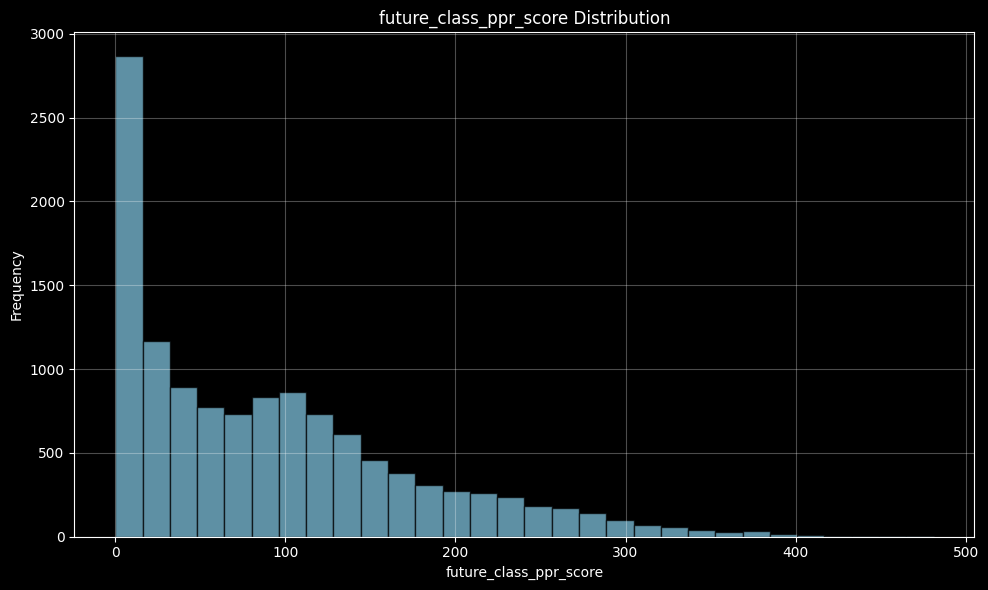

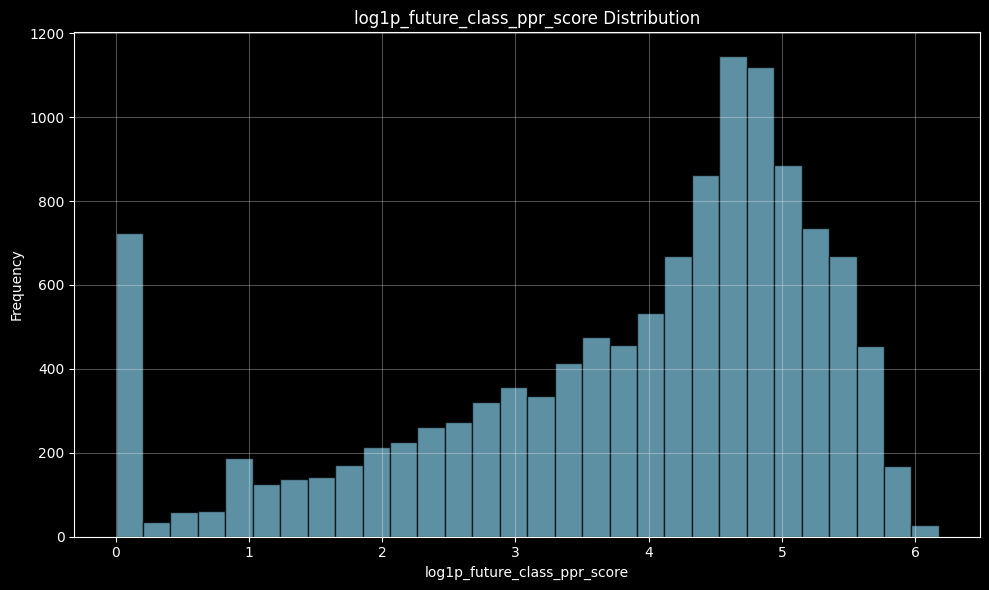

In [7]:
# display a histogram of future_class_ppr_score and log1p_future_class_ppr_score columns
data_utils.plot_histogram(combined_data_with_future_scores, 'future_class_ppr_score')
data_utils.plot_histogram(combined_data_with_future_scores, 'log1p_future_class_ppr_score')

In [8]:
# prepare output
path = pathlib.Path.cwd() / f"combined_data_with_future_scores_{beginning_season}_{end_season}"

In [9]:
data_utils.output_frame(combined_data_with_future_scores, path)

None


ModuleNotFoundError: Excel export requires 'xlsxwriter' not found.
Please install using the command `pip install xlsxwriter`.